--2026-05-08 15:03:52--  https://raw.githubusercontent.com/eretix5/Datasets/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 977501 (955K) [text/plain]
Saving to: ‘WA_Fn-UseC_-Telco-Customer-Churn.csv’

WA_Fn-UseC_-Telco-C 100%[===================>] 954.59K  --.-KB/s    in 0.05s   

2026-05-08 15:03:53 (17.8 MB/s) - ‘WA_Fn-UseC_-Telco-Customer-Churn.csv’ saved [977501/977501]

Анализ данных об оттоке клиентов
Размер данных: (7043, 21)
Колонки: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'Pay

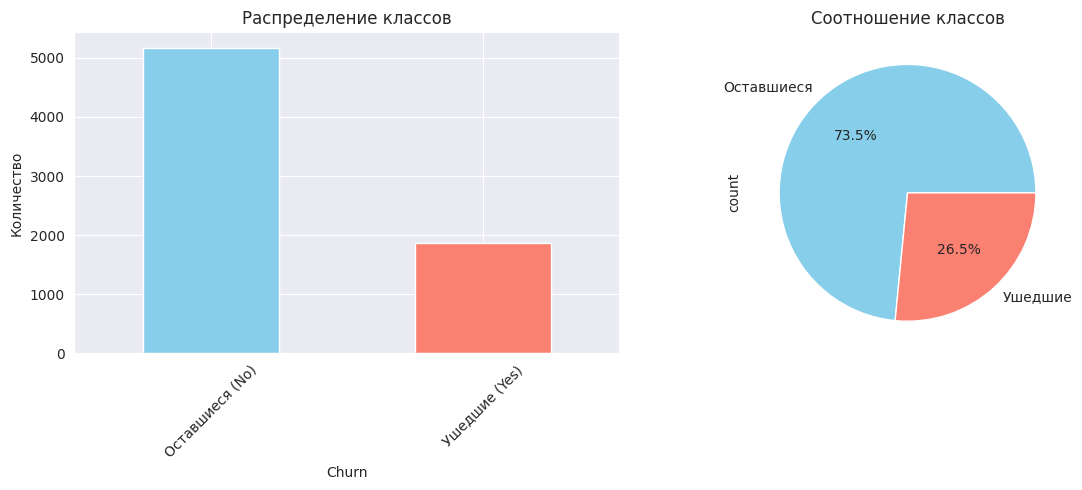

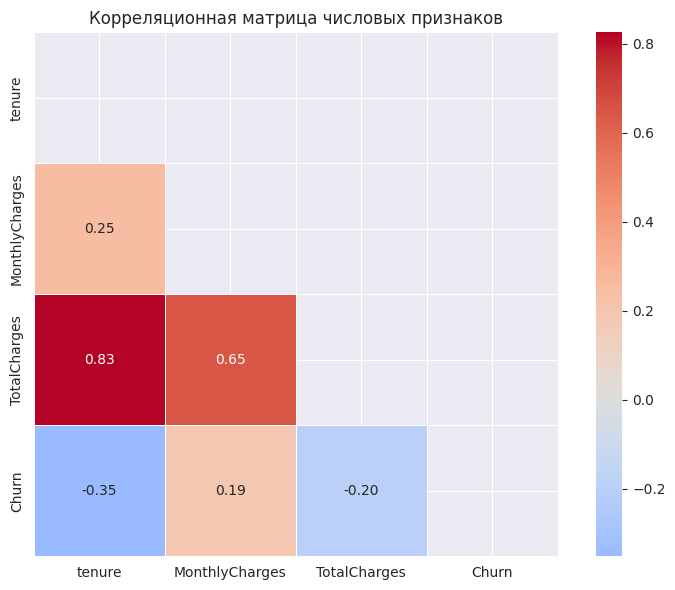

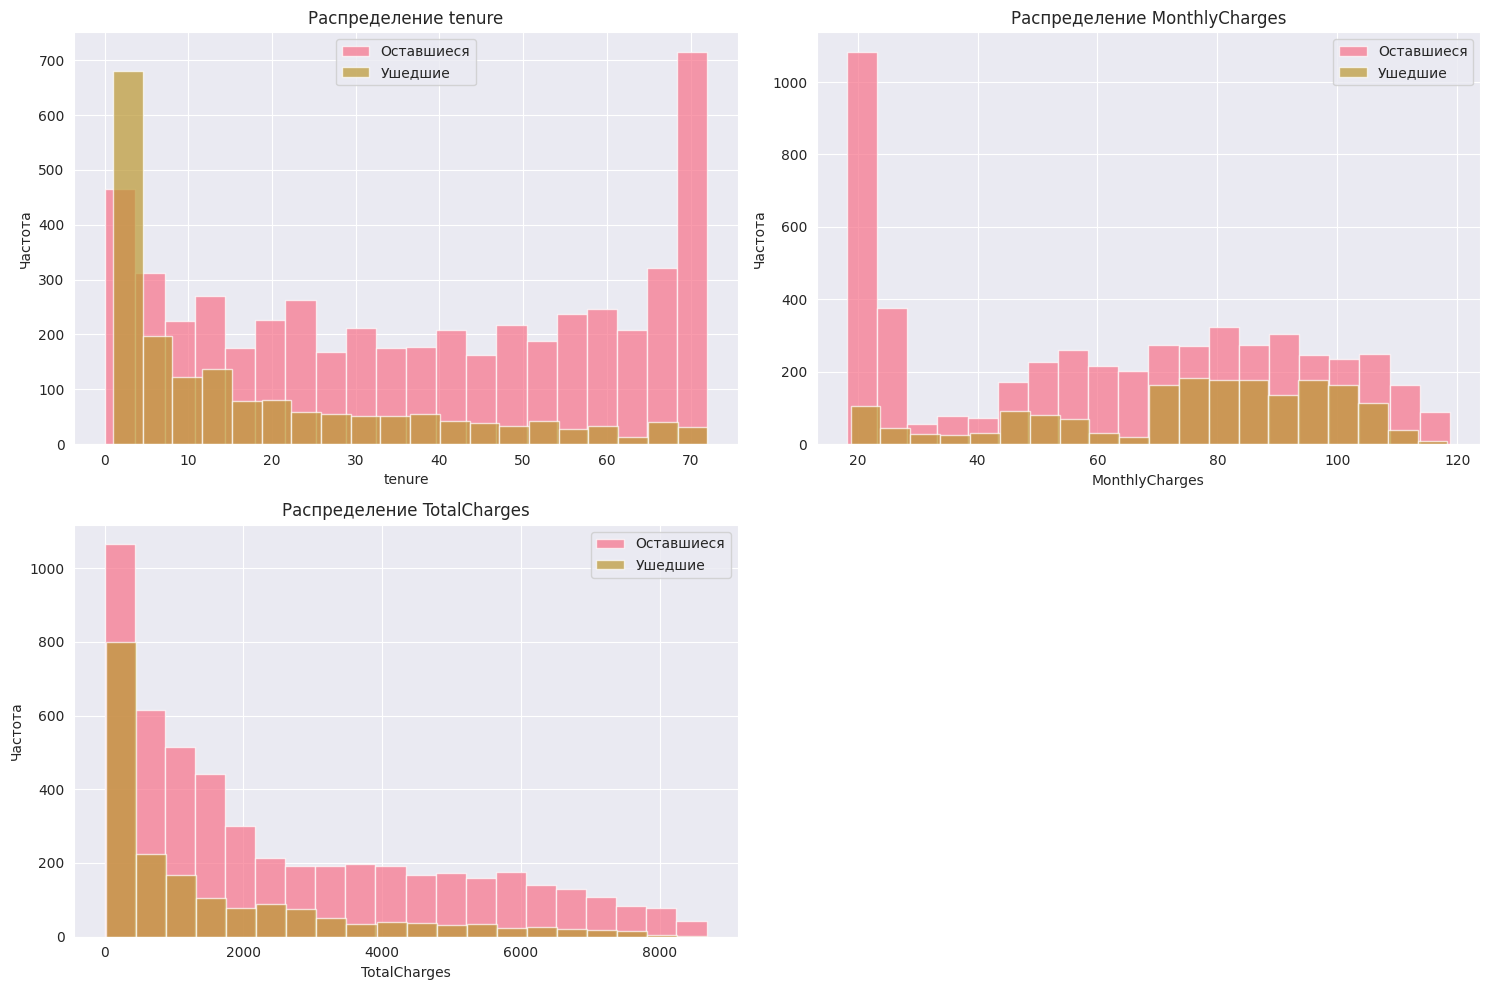

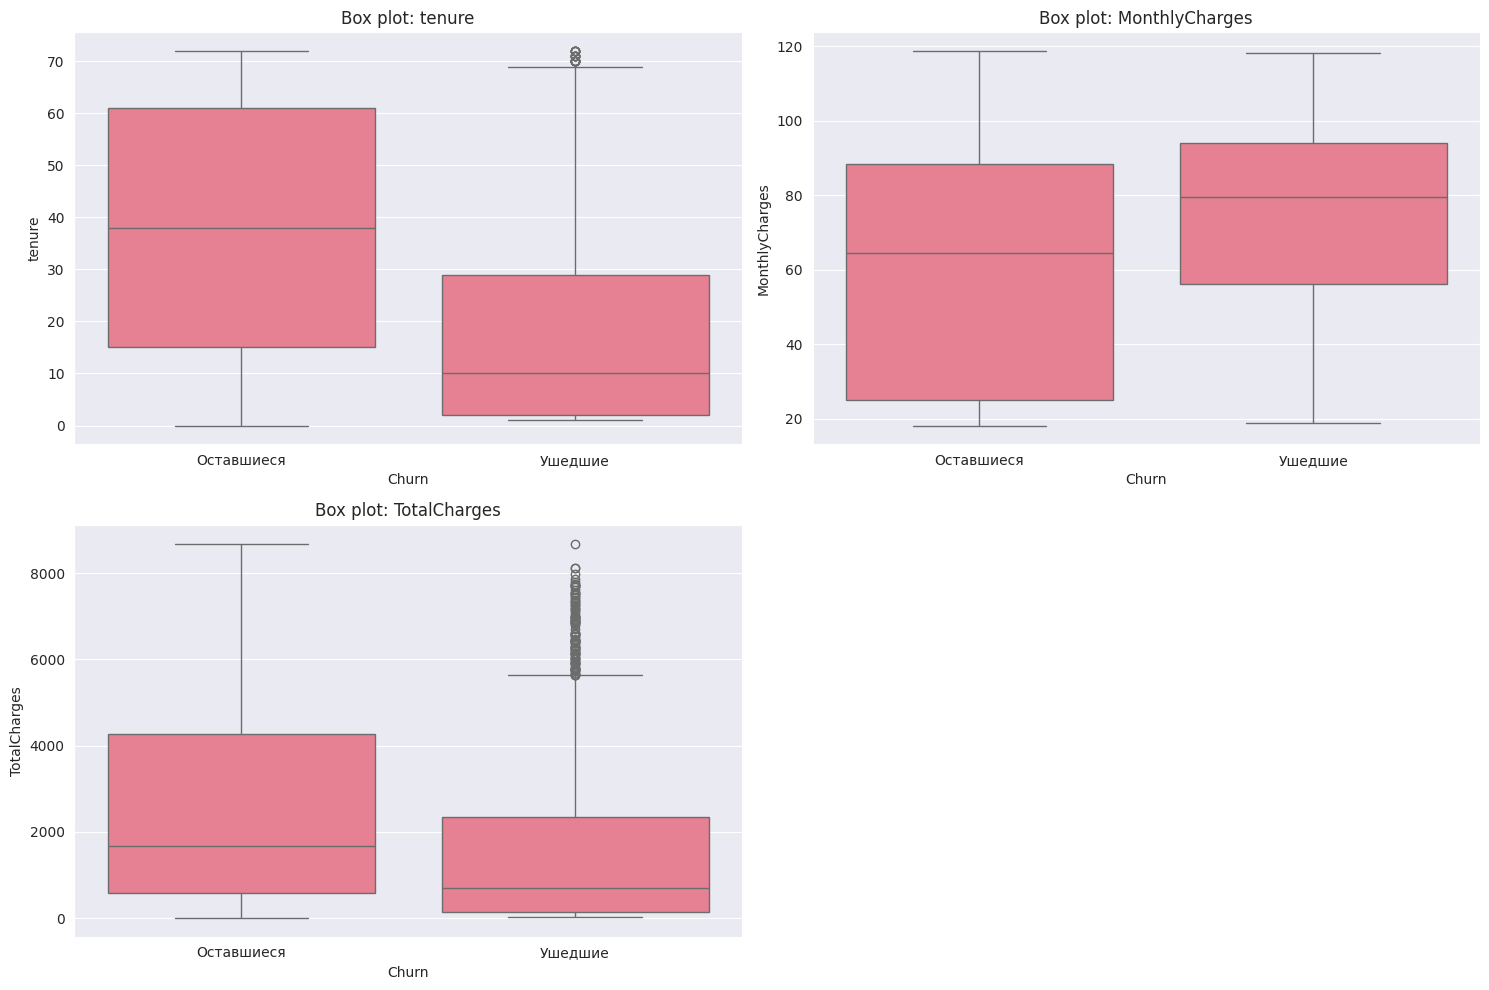


Размер обучающей выборки: (5634, 30)
Размер тестовой выборки: (1409, 30)

Обучение XGBoost...
XGBoost - Accuracy: 0.7438, ROC-AUC: 0.8344
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Обучение Random Forest...
Random Forest - Accuracy: 0.8048, ROC-AUC: 0.8316
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1035
           1       0.68      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Обучение SVM...
SVM - Accuracy: 0.7388, ROC-AUC: 0.8175
              precision    recall  f1-score   support

           0      

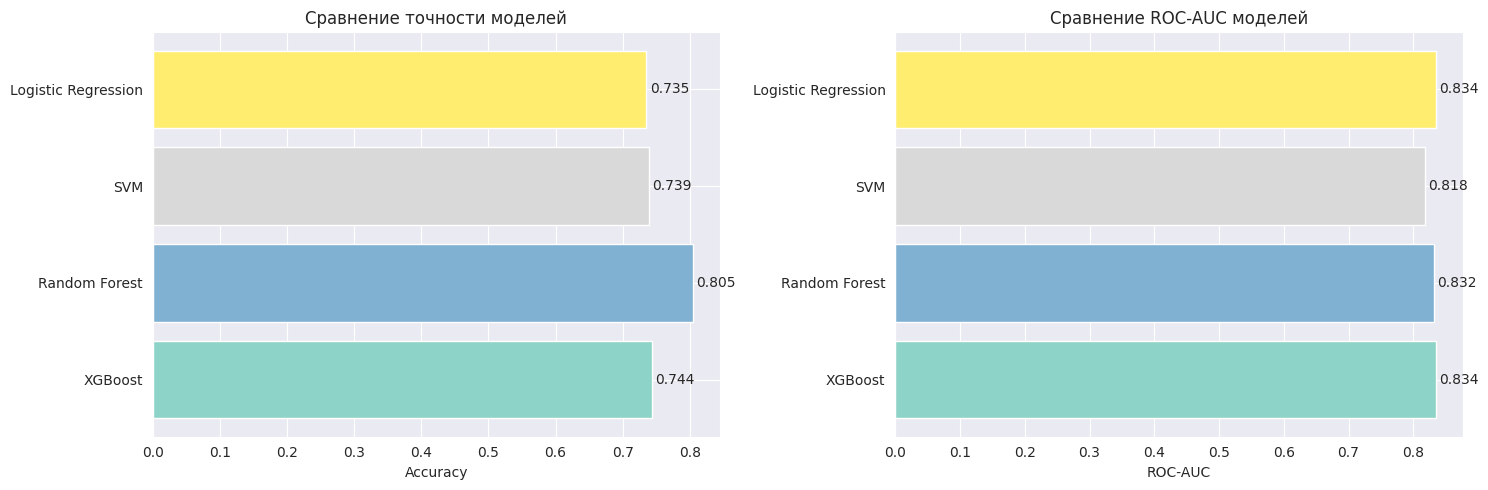

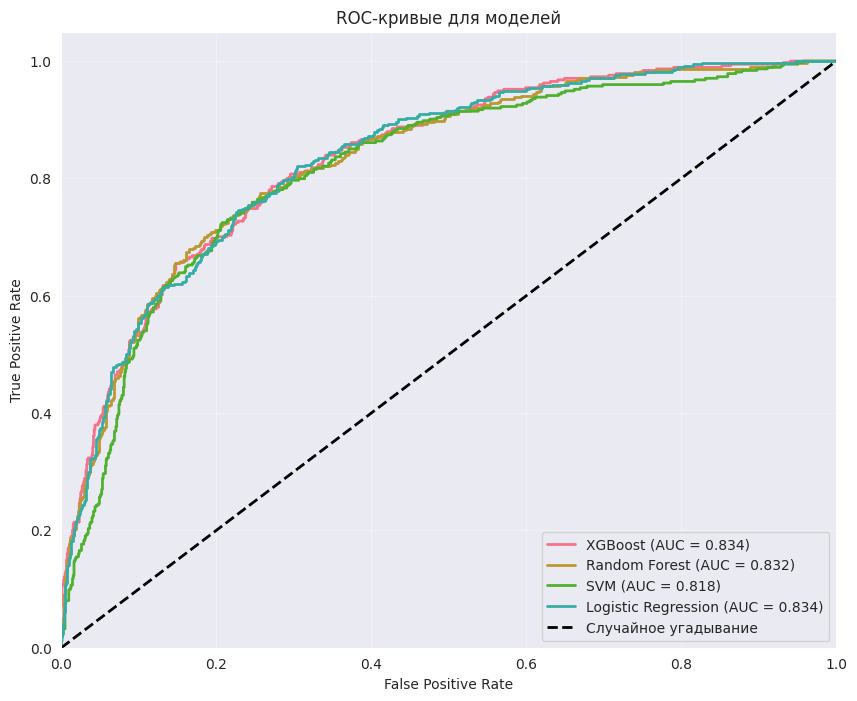

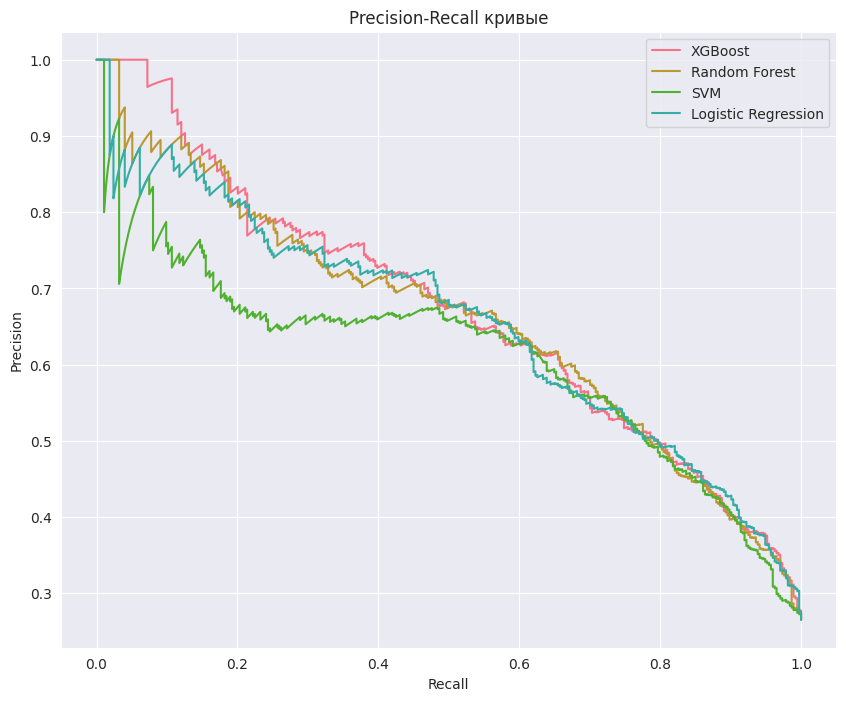

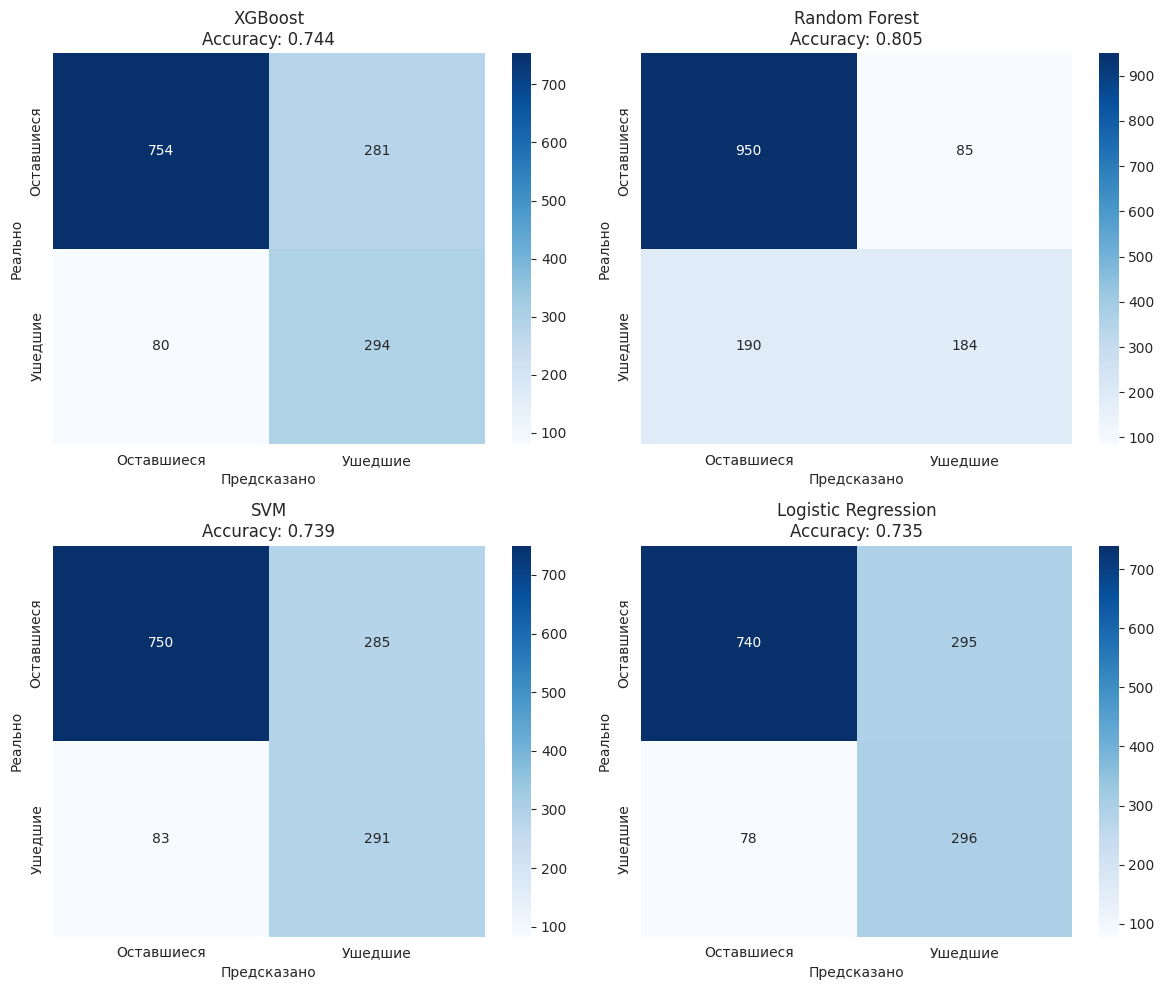

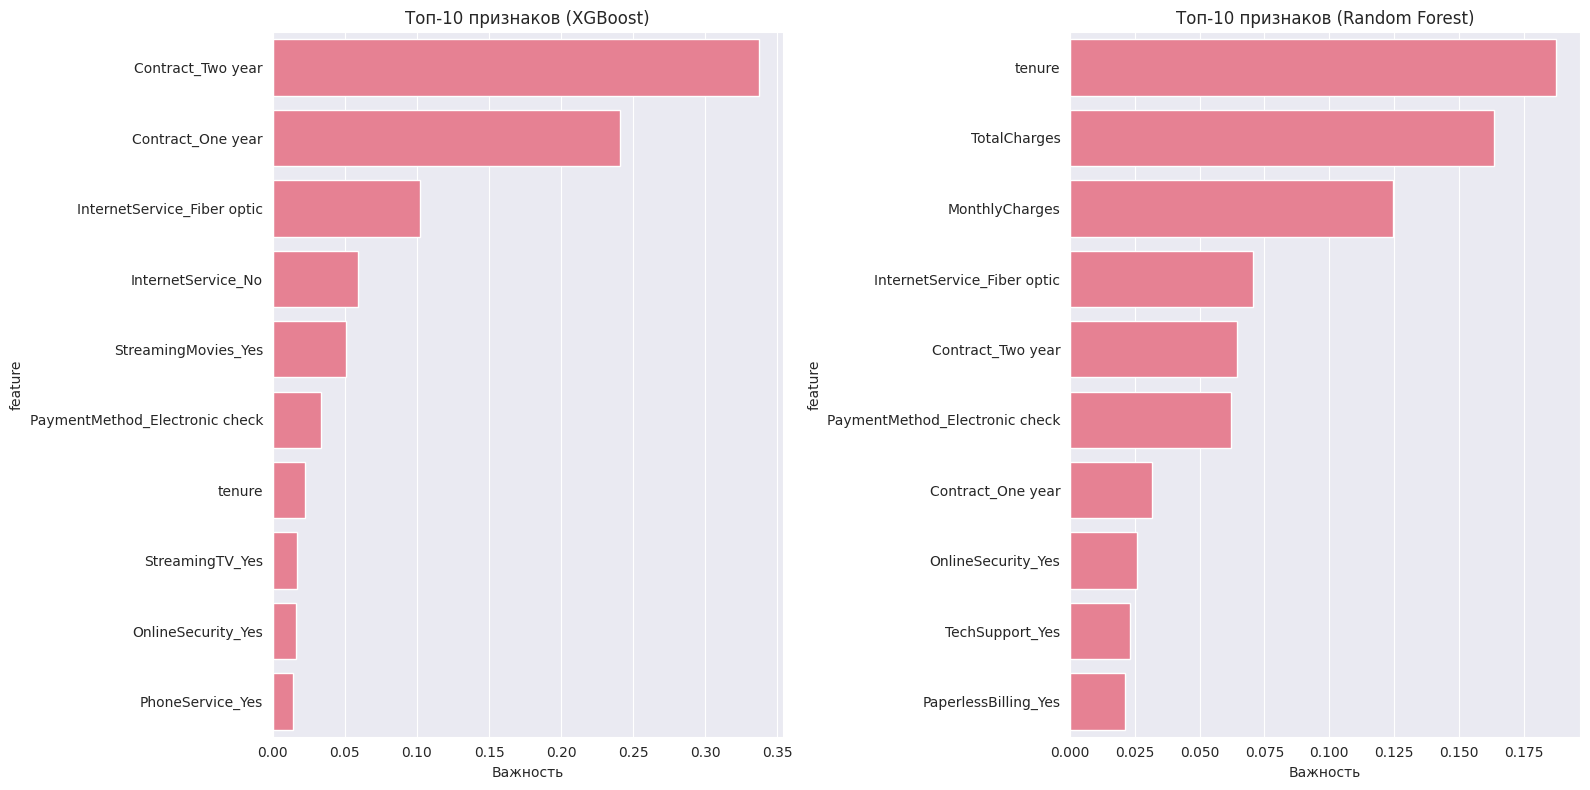


Топ-5 важных признаков (XGBoost):
                    feature  importance
          Contract_Two year    0.336873
          Contract_One year    0.240585
InternetService_Fiber optic    0.102014
         InternetService_No    0.059075
        StreamingMovies_Yes    0.050656

ИТОГОВЫЙ РЕЗУЛЬТАТ
Лучшая модель: Random Forest
Точность: 80.48%
ROC-AUC: 0.8316

Лучшая модель сохранена как best_model_Random Forest.pkl


In [1]:
"""
Customer Churn Prediction using Machine Learning
================================================================
Разработана модель машинного обучения для предсказания оттока клиентов телеком-компании.
Цель — снизить финансовые потери за счёт раннего выявления клиентов, склонных к уходу.

Метрики: Accuracy, Precision, Recall, F1, ROC-AUC
Модели: XGBoost, Random Forest, Logistic Regression, SVM
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score, precision_recall_curve
)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

!wget "https://raw.githubusercontent.com/eretix5/Datasets/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"

sns.set_style('darkgrid')
sns.set_palette("husl")


class CustomerChurnAnalysis:
    def __init__(self, data_path):
        self.data_path = data_path
        self.data = None
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.models = {}
        self.results = {}
        self.scaler = None

    def load_and_explore_data(self):
        """Загрузка и первичный анализ данных"""
        self.data = pd.read_csv(self.data_path)

        if 'TotalCharges' in self.data.columns:
            self.data['TotalCharges'] = pd.to_numeric(
                self.data['TotalCharges'], errors='coerce'
            )
            self.data['TotalCharges'] = self.data['TotalCharges'].fillna(0)

        print("=" * 50)
        print("Анализ данных об оттоке клиентов")
        print("=" * 50)
        print(f"Размер данных: {self.data.shape}")
        print(f"Колонки: {self.data.columns.tolist()}")
        print(f"\nПропущенные значения:\n{self.data.isnull().sum()}")
        print(f"\nСтатистика по целевому признаку:\n{self.data['Churn'].value_counts()}")
        print(f"\nОписательная статистика:\n{self.data.describe()}")

        # Визуализация распределения классов
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        self.data['Churn'].value_counts().plot(
            kind='bar', color=['skyblue', 'salmon']
        )
        plt.title('Распределение классов')
        plt.xticks([0, 1], ['Оставшиеся (No)', 'Ушедшие (Yes)'], rotation=45)
        plt.ylabel('Количество')

        plt.subplot(1, 2, 2)
        self.data['Churn'].value_counts().plot(
            kind='pie', autopct='%1.1f%%',
            colors=['skyblue', 'salmon'],
            labels=['Оставшиеся', 'Ушедшие']
        )
        plt.title('Соотношение классов')
        plt.tight_layout()
        plt.show()

    def visualize_features(self):
        # Числовые признаки для корреляции
        numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
        numeric_cols = [c for c in numeric_cols if c in self.data.columns]

        if numeric_cols:
            plt.figure(figsize=(8, 6))
            correlation_matrix = self.data[numeric_cols + ['Churn']].copy()
            # Переводим Churn в 0/1 для корреляции
            correlation_matrix['Churn'] = (correlation_matrix['Churn'] == 'Yes').astype(int)
            corr = correlation_matrix.corr()
            mask = np.triu(np.ones_like(corr, dtype=bool))
            sns.heatmap(
                corr, mask=mask, cmap='coolwarm',
                center=0, annot=True, fmt='.2f',
                square=True, linewidths=0.5
            )
            plt.title('Корреляционная матрица числовых признаков')
            plt.tight_layout()
            plt.show()

        # Распределение ключевых числовых признаков по классам
        key_features = numeric_cols

        if key_features:
            n = len(key_features)
            rows = int(np.ceil(n / 2))
            fig, axes = plt.subplots(rows, 2, figsize=(15, 5 * rows))
            axes = np.array(axes).ravel()

            for i, feature in enumerate(key_features):
                for churn_value in ['No', 'Yes']:
                    subset = self.data[self.data['Churn'] == churn_value]
                    label = 'Оставшиеся' if churn_value == 'No' else 'Ушедшие'
                    axes[i].hist(
                        subset[feature], alpha=0.7, label=label, bins=20
                    )
                axes[i].set_title(f'Распределение {feature}')
                axes[i].legend()
                axes[i].set_xlabel(feature)
                axes[i].set_ylabel('Частота')

            for j in range(len(key_features), len(axes)):
                axes[j].set_visible(False)

            plt.tight_layout()
            plt.show()

            # Box plots
            fig, axes = plt.subplots(rows, 2, figsize=(15, 5 * rows))
            axes = np.array(axes).ravel()
            for i, feature in enumerate(key_features):
                sns.boxplot(x='Churn', y=feature, data=self.data, ax=axes[i])
                axes[i].set_xticklabels(['Оставшиеся', 'Ушедшие'])
                axes[i].set_title(f'Box plot: {feature}')
            for j in range(len(key_features), len(axes)):
                axes[j].set_visible(False)
            plt.tight_layout()
            plt.show()

    """Подготовка данных для обучения"""
    def prepare_data(self):
        # Удаляем идентификатор
        df = self.data.copy()
        if 'customerID' in df.columns:
            df = df.drop(['customerID'], axis=1)

        # Целевая переменная
        df['Churn'] = (df['Churn'] == 'Yes').astype(int)

        # Признаки и целевая
        self.y = df['Churn']
        self.X = df.drop(['Churn'], axis=1)

        # Разделяем на числовые и категориальные признаки
        numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
        numeric_cols = [c for c in numeric_cols if c in self.X.columns]
        cat_cols = [c for c in self.X.columns if c not in numeric_cols]

        # One-hot encoding для категориальных признаков
        self.X = pd.get_dummies(self.X, columns=cat_cols, drop_first=True)

        # Train/test
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=1, stratify=self.y
        )

        # Масштабирование числовых признаков
        self.scaler = StandardScaler()
        self.X_train[numeric_cols] = self.scaler.fit_transform(self.X_train[numeric_cols])
        self.X_test[numeric_cols] = self.scaler.transform(self.X_test[numeric_cols])

        print(f"\nРазмер обучающей выборки: {self.X_train.shape}")
        print(f"Размер тестовой выборки: {self.X_test.shape}")

    def train_models(self):
        # Учитываем дисбаланс классов через scale_pos_weight для XGBoost
        pos_weight = (
            len(self.y_train[self.y_train == 0]) /
            len(self.y_train[self.y_train == 1])
        )

        # XGBoost
        self.models['XGBoost'] = xgb.XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            objective='binary:logistic', random_state=1,
            eval_metric='logloss',
            scale_pos_weight=pos_weight
        )

        # Random Forest
        self.models['Random Forest'] = RandomForestClassifier(
            n_estimators=200, max_depth=10, random_state=1
        )

        # SVM
        self.models['SVM'] = SVC(
            kernel='rbf', probability=True, random_state=1, class_weight='balanced'
        )

        # Logistic Regression
        self.models['Logistic Regression'] = LogisticRegression(
            class_weight='balanced', random_state=1, max_iter=1000
        )

        # Обучение и оценка
        for name, model in self.models.items():
            print(f"\nОбучение {name}...")
            model.fit(self.X_train, self.y_train)

            y_pred = model.predict(self.X_test)
            y_pred_proba = model.predict_proba(self.X_test)[:, 1]

            accuracy = accuracy_score(self.y_test, y_pred)
            roc_auc = roc_auc_score(self.y_test, y_pred_proba)

            self.results[name] = {
                'accuracy': accuracy,
                'roc_auc': roc_auc,
                'y_pred': y_pred,
                'y_pred_proba': y_pred_proba
            }

            print(f"{name} - Accuracy: {accuracy:.4f}, ROC-AUC: {roc_auc:.4f}")
            print(classification_report(self.y_test, y_pred))

    def compare_models(self):
        comparison_df = pd.DataFrame({
            name: [results['accuracy'], results['roc_auc']]
            for name, results in self.results.items()
        }, index=['Accuracy', 'ROC-AUC']).T

        print("\n" + "=" * 50)
        print("Сравнение моделей")
        print("=" * 50)
        print(comparison_df.sort_values('Accuracy', ascending=False))

        # Визуализация сравнения
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Accuracy
        accuracies = [results['accuracy'] for results in self.results.values()]
        models_names = list(self.results.keys())
        colors = plt.cm.Set3(np.linspace(0, 1, len(models_names)))

        axes[0].barh(models_names, accuracies, color=colors)
        axes[0].set_xlabel('Accuracy')
        axes[0].set_title('Сравнение точности моделей')
        for i, v in enumerate(accuracies):
            axes[0].text(v + 0.005, i, f'{v:.3f}', va='center')

        # ROC-AUC
        roc_aucs = [results['roc_auc'] for results in self.results.values()]
        axes[1].barh(models_names, roc_aucs, color=colors)
        axes[1].set_xlabel('ROC-AUC')
        axes[1].set_title('Сравнение ROC-AUC моделей')
        for i, v in enumerate(roc_aucs):
            axes[1].text(v + 0.005, i, f'{v:.3f}', va='center')

        plt.tight_layout()
        plt.show()

        return comparison_df

    def plot_roc_curves(self):
        plt.figure(figsize=(10, 8))

        for name, results in self.results.items():
            fpr, tpr, _ = roc_curve(self.y_test, results['y_pred_proba'])
            roc_auc = results['roc_auc']
            plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

        plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Случайное угадывание')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC-кривые для моделей')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.show()

    def plot_precision_recall(self):
        plt.figure(figsize=(10,8))
        for name, results in self.results.items():
            precision, recall, _ = precision_recall_curve(
                self.y_test, results['y_pred_proba']
            )
            plt.plot(recall, precision, label=name)

        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall кривые")
        plt.legend()
        plt.show()

    def plot_confusion_matrices(self):
        n_models = len(self.models)
        n_cols = 2
        n_rows = (n_models + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
        axes = axes.flatten() if n_models > 1 else [axes]

        for idx, (name, results) in enumerate(self.results.items()):
            cm = confusion_matrix(self.y_test, results['y_pred'])
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Оставшиеся', 'Ушедшие'],
                yticklabels=['Оставшиеся', 'Ушедшие'],
                ax=axes[idx]
            )
            axes[idx].set_xlabel('Предсказано')
            axes[idx].set_ylabel('Реально')
            axes[idx].set_title(f'{name}\nAccuracy: {results["accuracy"]:.3f}')

        for idx in range(len(self.models), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.show()

    def analyze_feature_importance(self):
        # Для XGBoost
        xgb_model = self.models['XGBoost']
        feature_importance = pd.DataFrame({
            'feature': self.X.columns,
            'importance': xgb_model.feature_importances_
        }).sort_values('importance', ascending=False)

        # Для Random Forest
        rf_model = self.models['Random Forest']
        rf_importance = pd.DataFrame({
            'feature': self.X.columns,
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False)

        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        sns.barplot(
            data=feature_importance.head(10),
            x='importance', y='feature', ax=axes[0]
        )
        axes[0].set_title('Топ-10 признаков (XGBoost)')
        axes[0].set_xlabel('Важность')

        sns.barplot(
            data=rf_importance.head(10),
            x='importance', y='feature', ax=axes[1]
        )
        axes[1].set_title('Топ-10 признаков (Random Forest)')
        axes[1].set_xlabel('Важность')

        plt.tight_layout()
        plt.show()

        print("\nТоп-5 важных признаков (XGBoost):")
        print(feature_importance.head(5).to_string(index=False))

    def run_analysis(self):
        self.load_and_explore_data()
        self.visualize_features()
        self.prepare_data()
        self.train_models()
        comparison = self.compare_models()
        self.plot_roc_curves()
        self.plot_precision_recall()
        self.plot_confusion_matrices()
        self.analyze_feature_importance()

        best_model = comparison['Accuracy'].idxmax()
        best_accuracy = comparison.loc[best_model, 'Accuracy']
        print("\n" + "=" * 50)
        print("ИТОГОВЫЙ РЕЗУЛЬТАТ")
        print("=" * 50)
        print(f"Лучшая модель: {best_model}")
        print(f"Точность: {best_accuracy * 100:.2f}%")
        print(f"ROC-AUC: {comparison.loc[best_model, 'ROC-AUC']:.4f}")

        return best_model


if __name__ == "__main__":
    analysis = CustomerChurnAnalysis('WA_Fn-UseC_-Telco-Customer-Churn.csv')
    best_model = analysis.run_analysis()

    import joblib
    joblib.dump(analysis.models[best_model], f'best_model_{best_model}.pkl')
    joblib.dump(analysis.scaler, 'scaler.pkl')
    print(f"\nЛучшая модель сохранена как best_model_{best_model}.pkl")
